# GMM Clustering Notebook

#### Importing needed packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

#### Readin the data

In [2]:
sys.path.append('..')

from src.data import load_data
df = load_data('../data/cleaned_log_data.csv')
df.head()

,Unnamed: 0,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0,2,3,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,1,2,3,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,2,2,3,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,3,1,3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,4,2,3,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718


In [3]:
df.shape

(395, 9)

#### Transform data to numpy nd array

In [4]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen']

X_data = np.asanyarray(df[features])
X_data

array([[ 9.44699227,  9.17543832,  8.93089098,  5.37063803,  7.89170466,
         7.19967835],
       [ 8.861917  ,  9.19125948,  9.16628399,  7.47477218,  8.09985791,
         7.48268183],
       [ 8.75683981,  9.08352921,  8.94702566,  7.7857209 ,  8.16536363,
         8.96763167],
       ...,
       [10.57717155,  7.26682735,  6.63987583,  8.41427414,  4.54329478,
         7.7608932 ],
       [ 9.58410839,  9.64788537, 10.3170531 ,  6.08221891,  9.60521628,
         7.53262362],
       [ 9.23902501,  7.59186171,  7.71110125,  6.94601399,  5.12989871,
         7.66199756]], shape=(395, 6))

#### Visualizing the pattern of scaled data

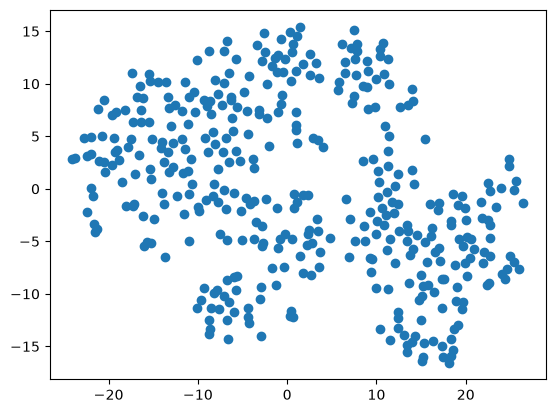

In [6]:
from src.clustering import tsne_model
from sklearn.preprocessing import StandardScaler
X_s = StandardScaler().fit_transform(X_data)
model = tsne_model(X_s)
plt.scatter(model[:,0] , model[:,1])

#### Model training

k=2, cov=full, BIC=5781.77, AIC=5562.93
k=3, cov=full, BIC=5826.33, AIC=5496.08
k=4, cov=full, BIC=5907.28, AIC=5465.63
k=5, cov=full, BIC=6000.54, AIC=5447.48
k=6, cov=full, BIC=6087.83, AIC=5423.36
k=7, cov=full, BIC=6199.18, AIC=5423.30
k=8, cov=full, BIC=6303.85, AIC=5416.56
k=9, cov=full, BIC=6378.63, AIC=5379.93
k=10, cov=full, BIC=6522.92, AIC=5412.82
k=2, cov=tied, BIC=5909.61, AIC=5774.33
k=3, cov=tied, BIC=5897.00, AIC=5733.87
k=4, cov=tied, BIC=5900.13, AIC=5709.14
k=5, cov=tied, BIC=5894.58, AIC=5675.75
k=6, cov=tied, BIC=5881.35, AIC=5634.66
k=7, cov=tied, BIC=5897.94, AIC=5623.39
k=8, cov=tied, BIC=5926.58, AIC=5624.18
k=9, cov=tied, BIC=5934.30, AIC=5604.05
k=10, cov=tied, BIC=5951.26, AIC=5593.16
k=2, cov=diag, BIC=6261.99, AIC=6162.52
k=3, cov=diag, BIC=6169.52, AIC=6018.32
k=4, cov=diag, BIC=6090.82, AIC=5887.90
k=5, cov=diag, BIC=6063.43, AIC=5808.78
k=6, cov=diag, BIC=6053.76, AIC=5747.39
k=7, cov=diag, BIC=6044.64, AIC=5686.54
k=8, cov=diag, BIC=6067.55, AIC=5657.7

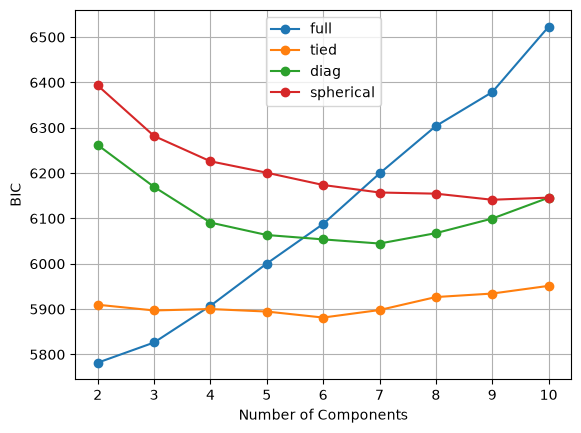

In [5]:
from src.clustering import GMM_model
labels = GMM_model(X_data, 'labels')

#### This chart and the results obtained from the model indicate that, based on the `BIC` value—arguably the `most important` criterion for GMM, two clusters and `full` covariance structure yield the **best** results for this dataset.

#### Visualising clustering resut

Text(0.5, 1.0, 'GMM Clustering')

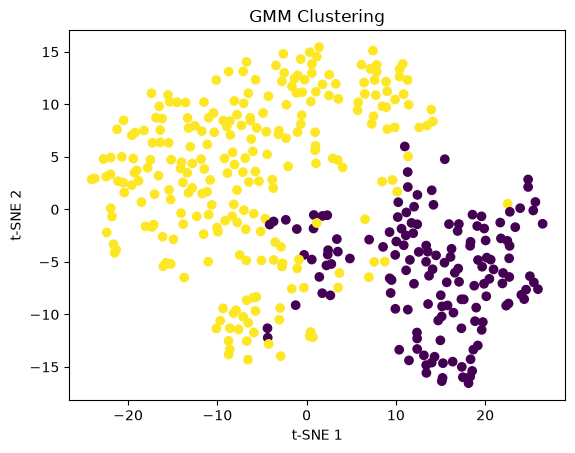

In [7]:
from src.clustering import tsne_model
X_scaled = StandardScaler().fit_transform(X_data)

tsne_vis = tsne_model(X_scaled)

plt.scatter(tsne_vis[: , 0], tsne_vis[: , 1] , c = labels)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('GMM Clustering')

#### Scoring for comparison amung GMM and another models

In [10]:
from sklearn.metrics import silhouette_score
print(silhouette_score(X_scaled, labels))

0.267253716992808


#### Interpretation

##### Probability of customer for any cluster

k=2, cov=full, BIC=5781.77, AIC=5562.93
k=3, cov=full, BIC=5826.33, AIC=5496.08
k=4, cov=full, BIC=5907.28, AIC=5465.63
k=5, cov=full, BIC=6000.54, AIC=5447.48
k=6, cov=full, BIC=6087.83, AIC=5423.36
k=7, cov=full, BIC=6199.18, AIC=5423.30
k=8, cov=full, BIC=6303.85, AIC=5416.56
k=9, cov=full, BIC=6378.63, AIC=5379.93
k=10, cov=full, BIC=6522.92, AIC=5412.82
k=2, cov=tied, BIC=5909.61, AIC=5774.33
k=3, cov=tied, BIC=5897.00, AIC=5733.87
k=4, cov=tied, BIC=5900.13, AIC=5709.14
k=5, cov=tied, BIC=5894.58, AIC=5675.75
k=6, cov=tied, BIC=5881.35, AIC=5634.66
k=7, cov=tied, BIC=5897.94, AIC=5623.39
k=8, cov=tied, BIC=5926.58, AIC=5624.18
k=9, cov=tied, BIC=5934.30, AIC=5604.05
k=10, cov=tied, BIC=5951.26, AIC=5593.16
k=2, cov=diag, BIC=6261.99, AIC=6162.52
k=3, cov=diag, BIC=6169.52, AIC=6018.32
k=4, cov=diag, BIC=6090.82, AIC=5887.90
k=5, cov=diag, BIC=6063.43, AIC=5808.78
k=6, cov=diag, BIC=6053.76, AIC=5747.39
k=7, cov=diag, BIC=6044.64, AIC=5686.54
k=8, cov=diag, BIC=6067.55, AIC=5657.7

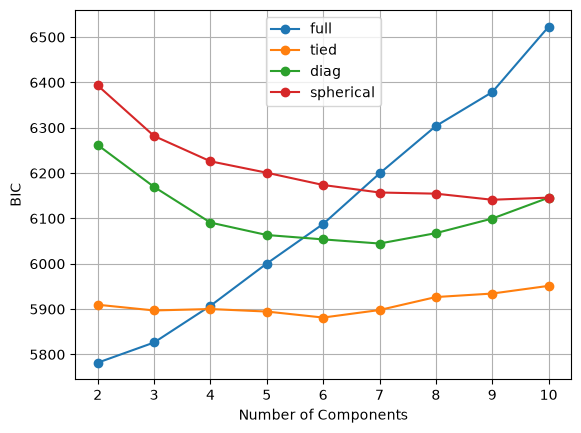

In [8]:
labels_proba = GMM_model(X_data, 'proba')

In [9]:
labels_proba['Cluster'] = labels
labels_proba.head()

,Cluster_0_Prob,Cluster_1_Prob,Cluster
0,0.973783,0.026217,0
1,0.982272,0.017728,0
2,0.978372,0.021628,0
3,0.000005,0.999995,1
4,0.807611,0.192389,0


In [11]:
df_exp = df.copy()
df_exp['labels'] = labels

In [12]:
cluster_profile = (df_exp.groupby('labels')[features].agg(['mean', 'median']))
cluster_profile

Fresh                Milk             Grocery              Frozen  \
            mean    median      mean    median      mean    median      mean   
labels                                                                         
0       8.637467  8.732788  8.896770  8.869117  9.353975  9.310729  6.930151   
1       9.102703  9.260222  7.656843  7.602888  7.854073  7.812985  7.724072   

                 Detergents_Paper           Delicassen            
          median             mean    median       mean    median  
labels                                                            
0       7.018402         8.483256  8.432942   7.026257  7.234898  
1       7.748027         5.780644  5.849287   6.683062  6.727432

#### Count of customers in clusters

In [13]:
cluster_size = df_exp['labels'].value_counts().sort_index()
cluster_size

labels
0    147
1    248
Name: count, dtype: int64

#### Percentage of cluster labels relative to the Region

In [14]:
pd.crosstab(df_exp['labels'], df_exp['Region'], normalize= 'index')

Region,1,2,3
labels,,,
0,0.136054,0.108844,0.755102
1,0.213710,0.108871,0.677419


#### Percentage of cluster labels relative to the Channels

In [16]:
pd.crosstab(df_exp['labels'], df_exp['Channel'], normalize="index")

Channel,1,2
labels,,
0,0.224490,0.775510
1,0.967742,0.032258


#### Cluster profile with Z-Score, it shows the different between cluster mean and overal mean for any features

In [17]:
df_Z = pd.DataFrame(index=sorted(df_exp['labels'].unique()))

for feature in features:
    cluster_mean = df_exp.groupby('labels')[feature].mean()
    overall_mean = df_exp[feature].mean()
    overall_std = df_exp[feature].std()
    
    df_Z[feature] = (cluster_mean - overall_mean) / overall_std

df_Z

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,-0.26126,0.779337,0.932072,-0.443974,1.058057,0.215674
1,0.15486,-0.461946,-0.552478,0.263162,-0.627155,-0.127839


#### Shwoing the pattern using heatmap

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

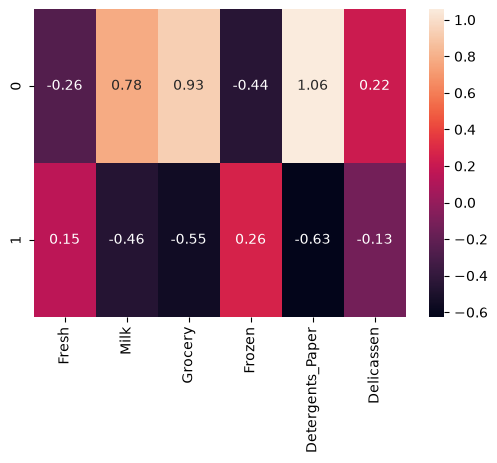

In [19]:
plt.figure(figsize= (6 , 4))
sns.heatmap(data= df_Z, annot= True, fmt= '.2f')
plt.show()

## Conclusion

After evaluating GMM with different numbers of clusters, the best result was obtained with **K = 2**, achieving a **Silhouette Score of 0.2672**.

This score indicates a relatively weak-to-moderate separation between the clusters. Therefore, while GMM was able to identify some structure in the dataset, the resulting clusters are not strongly separated.

The important different in this model `GMM` is `proba` which determines the probability of each customer belonging to each cluster.

In any case, the results derived from the **GMM algorithm** in this notebook **(without employing dimensionality reduction techniques)** indicate the presence of `two` clusters, comprising `147` and `248` customers, respectively; this means that `37.21%` of the customers fall into the first group and `62.78%` into the second

The first group purchased `Milk`, `Grocery`, `Detergents Paper` and `Delication` products more frequently than the second group.

An analysis based on **region** reveals that customers from regions `1` and `2` predominantly fall into the **second group**, whereas those from region `3` are mostly in the **first group**. Similarly, the majority of customers with `Channel 1` are in the **second group**, while the majority of those with `Channel 2` are in the **first group**.

Purchasing patterns for the products, broken down by cluster, are also presented.

| Cluster | Fresh     | Milk      | Grocery   | Frozen    | Detergents_Paper | Delicassen |
|---------|-----------|-----------|-----------|-----------|------------------|------------|
| 0       | -0.26126  | 0.779337  | 0.932072  | -0.443974 | 1.058057         | 0.215674   |
| 1       | 0.15486   | -0.461946 | -0.552478 | 0.263162  |-0.627155         | -0.127839  | 
